In [1]:
from pathlib import Path
import pandas as pd

BASE = Path("/cluster/project/reddy/katja/NGS_pipeline/data/P3408_LUCA-TCRA3/extracted")

lib_file    = BASE / "GFB-61840_cliboriginallib.filtered.PASS.aa.tsv"
neg_file    = BASE / "GFB-61815_clibKH1602xnegative.filtered.PASS.aa.tsv"
pos3x_file  = BASE / "GFB-61826_clibKH1603xpositive.filtered.PASS.aa.tsv"
posgfp_file = BASE / "GFB-61835_clibKH16031xpositive.filtered.PASS.aa.tsv"

def load_aa_file(path):
    df = pd.read_csv(path, sep="\t")
    print(path.name, "rows:", len(df))
    return df

lib_df    = load_aa_file(lib_file)
neg_df    = load_aa_file(neg_file)
pos3x_df  = load_aa_file(pos3x_file)
posgfp_df = load_aa_file(posgfp_file)

lib_df.head()


GFB-61840_cliboriginallib.filtered.PASS.aa.tsv rows: 6521633
GFB-61815_clibKH1602xnegative.filtered.PASS.aa.tsv rows: 5545371
GFB-61826_clibKH1603xpositive.filtered.PASS.aa.tsv rows: 2785364
GFB-61835_clibKH16031xpositive.filtered.PASS.aa.tsv rows: 2252331


,read_id,nt_seq,aa_seq,mutated_positions
0,TCGCCTGGAGCC|n=3,GCAAGTGGCGTCAGCATGGCGAACGAGCTATTC,ASGVSMANELF,NaN
1,AACTTGATATTC|n=9,GCGAGTGGTCCTAGCACCGTAAGTGAACAATTT,ASGPSTVSEQF,NaN
2,TCTCATCATTTT|n=34,GCCGGCAGTAACAACCCCGCCGATGAACTGTTT,AGSNNPADELF,NaN
3,CCGATTGTGGTA|n=14,CCGGGCGGCGTTAGTCTCGTTAACGGGCAATTC,PGGVSLVNGQF,NaN
4,CAGGCCCAAAGT|n=6,GCCAGCAGCCCGAATATGGCGGATGAACAGTAC,ASSPNMADEQY,NaN


In [2]:
def count_variants(df, label):
    counts = (
        df.groupby("aa_seq")
          .size()
          .reset_index(name=f"count_{label}")
    )
    total = counts[f"count_{label}"].sum()
    counts[f"freq_{label}"] = counts[f"count_{label}"] / total
    return counts

lib_counts_df   = count_variants(lib_df, "lib")
neg_counts_df   = count_variants(neg_df, "neg")
pos3x_counts_df  = count_variants(pos3x_df, "pos3x")
posgfp_counts_df = count_variants(posgfp_df, "posgfp")

print("Unique variants:")
print("Library:", len(lib_counts_df))
print("Negative:", len(neg_counts_df))
print("Pos3x:", len(pos3x_counts_df))
print("Pos3x+GFP:", len(posgfp_counts_df))

# Example
lib_counts_df.head()


Unique variants:
Library: 140338
Negative: 103493
Pos3x: 17474
Pos3x+GFP: 8877


,aa_seq,count_lib,freq_lib
0,AGGANAADELF,89,1.364689e-05
1,AGGANAADELY,2,3.066717e-07
2,AGGANAADEQF,1,1.533358e-07
3,AGGANAADEQY,30,4.600075e-06
4,AGGANAADGLY,80,1.226687e-05


In [4]:
pos3x_counts_df.sort_values("count_pos3x", ascending=False).head(10)
posgfp_counts_df.sort_values("count_posgfp", ascending=False).head(10)

,aa_seq,count_posgfp,freq_posgfp
8141,PGGVNLVSEQF,97934,0.043481
56,AGGANNVDEQY,67797,0.030101
1179,AGGTNLVDEQF,40983,0.018196
6095,ASSINVVNEQF,40719,0.018079
3252,ASGASVVSGQF,35694,0.015848
813,AGGNSIVSGQY,32495,0.014427
7854,ASSVNTVDGQY,31410,0.013946
6144,ASSISIVSGLF,28638,0.012715
1341,AGGVNIVDGQY,27363,0.012149
131,AGGASTVDEQF,26624,0.011821


In [5]:
# Merge everything on sequence (outer join keeps all variants)
merged = lib_counts_df.merge(neg_counts_df, on="aa_seq", how="outer") \
                   .merge(pos3x_counts_df, on="aa_seq", how="outer") \
                   .merge(posgfp_counts_df, on="aa_seq", how="outer")

# Replace missing frequencies with 0
merged = merged.fillna(0)

merged.head()


,aa_seq,count_lib,freq_lib,count_neg,freq_neg,count_pos3x,freq_pos3x,count_posgfp,freq_posgfp
0,AGGANAADELF,89.0,1.364689e-05,81.0,1.460678e-05,0.0,0.0,0.0,0.0
1,AGGANAADELY,2.0,3.066717e-07,1.0,1.803306e-07,0.0,0.0,0.0,0.0
2,AGGANAADEQF,1.0,1.533358e-07,3.0,5.409918e-07,0.0,0.0,0.0,0.0
3,AGGANAADEQY,30.0,4.600075e-06,42.0,7.573885e-06,0.0,0.0,0.0,0.0
4,AGGANAADGLY,80.0,1.226687e-05,416.0,7.501752e-05,0.0,0.0,0.0,0.0


In [6]:
PSEUDO = 1e-9

merged["enrich_pos3x_vs_neg"] = (
    (merged["freq_pos3x"] + PSEUDO) /
    (merged["freq_neg"] + PSEUDO)
)

merged["enrich_posgfp_vs_neg"] = (
    (merged["freq_posgfp"] + PSEUDO) /
    (merged["freq_neg"] + PSEUDO)
)

merged["enrich_pos3x_vs_lib"] = (
    (merged["freq_pos3x"] + PSEUDO) /
    (merged["freq_lib"] + PSEUDO)
)

merged["enrich_posgfp_vs_lib"] = (
    (merged["freq_posgfp"] + PSEUDO) /
    (merged["freq_lib"] + PSEUDO)
)


In [7]:
merged.sort_values("enrich_posgfp_vs_neg", ascending=False).head(20)


,aa_seq,count_lib,freq_lib,count_neg,freq_neg,count_pos3x,freq_pos3x,count_posgfp,freq_posgfp,enrich_pos3x_vs_neg,enrich_posgfp_vs_neg,enrich_pos3x_vs_lib,enrich_posgfp_vs_lib
1562,AGGASTVDEQF,354.0,0.000054,0.0,0.0,15070.0,0.005410,26624.0,0.011821,5.410425e+06,1.182064e+07,99.672756,217.764067
32791,AGSINEASELY,128.0,0.000020,0.0,0.0,10512.0,0.003774,23528.0,0.010446,3.774014e+06,1.044607e+07,192.277191,532.202730
50818,AGSVNVADGLF,217.0,0.000033,0.0,0.0,2972.0,0.001067,14175.0,0.006293,1.067007e+06,6.293481e+06,32.066446,189.136127
42443,AGSPSLVDEQF,196.0,0.000030,0.0,0.0,4500.0,0.001616,13123.0,0.005826,1.615589e+06,5.826409e+06,53.754727,193.859382
83087,ASSDSNVDEQF,175.0,0.000027,0.0,0.0,8361.0,0.003002,11103.0,0.004930,3.001763e+06,4.929561e+06,111.860958,183.700499
59441,ASGHSIVDGLY,413.0,0.000063,0.0,0.0,4289.0,0.001540,9322.0,0.004139,1.539836e+06,4.138824e+06,24.314974,65.354641
62336,ASGKNLVNGQY,308.0,0.000047,0.0,0.0,6466.0,0.002321,9268.0,0.004115,2.321421e+06,4.114849e+06,49.153039,87.126518
95340,ASSMNVVSEQY,136.0,0.000021,0.0,0.0,4529.0,0.001626,8714.0,0.003869,1.626000e+06,3.868882e+06,77.968154,185.516301
1232,AGGASMADGQF,163.0,0.000025,0.0,0.0,1870.0,0.000671,7641.0,0.003392,6.713675e+05,3.392486e+06,26.860350,135.728012
71611,ASGQNVVGEQF,164.0,0.000025,0.0,0.0,5450.0,0.001957,5945.0,0.002639,1.956657e+06,2.639489e+06,77.805447,104.957879


In [8]:
merged.sort_values("enrich_pos3x_vs_neg", ascending=False).head(20)


,aa_seq,count_lib,freq_lib,count_neg,freq_neg,count_pos3x,freq_pos3x,count_posgfp,freq_posgfp,enrich_pos3x_vs_neg,enrich_posgfp_vs_neg,enrich_pos3x_vs_lib,enrich_posgfp_vs_lib
1562,AGGASTVDEQF,354.0,0.000054,0.0,0.0,15070.0,0.005410,26624.0,0.011821,5.410425e+06,1.182064e+07,99.672756,217.764067
3884,AGGESLVDEQY,300.0,0.000046,0.0,0.0,13213.0,0.004744,3824.0,0.001698,4.743726e+06,1.697798e+06,103.120552,36.907241
32791,AGSINEASELY,128.0,0.000020,0.0,0.0,10512.0,0.003774,23528.0,0.010446,3.774014e+06,1.044607e+07,192.277191,532.202730
83087,ASSDSNVDEQF,175.0,0.000027,0.0,0.0,8361.0,0.003002,11103.0,0.004930,3.001763e+06,4.929561e+06,111.860958,183.700499
88748,ASSHSVVGEQY,913.0,0.000140,0.0,0.0,6689.0,0.002401,5937.0,0.002636,2.401482e+06,2.635937e+06,17.153861,18.828576
62336,ASGKNLVNGQY,308.0,0.000047,0.0,0.0,6466.0,0.002321,9268.0,0.004115,2.321421e+06,4.114849e+06,49.153039,87.126518
876,AGGANVVSEQF,216.0,0.000033,0.0,0.0,6442.0,0.002313,3816.0,0.001694,2.312805e+06,1.694246e+06,69.827813,51.152386
149453,PSSLNEVDEQY,187.0,0.000029,0.0,0.0,6277.0,0.002254,2899.0,0.001287,2.253566e+06,1.287112e+06,78.590485,44.886521
71611,ASGQNVVGEQF,164.0,0.000025,0.0,0.0,5450.0,0.001957,5945.0,0.002639,1.956657e+06,2.639489e+06,77.805447,104.957879
3388,AGGENLASGLY,114.0,0.000017,0.0,0.0,4831.0,0.001734,1544.0,0.000686,1.734424e+06,6.855130e+05,99.216063,39.214111


In [9]:
import numpy as np

# thresholds (edit if you want)
ENRICH_UP = 2.0
ENRICH_DOWN = 0.5

# practical filters to reduce noise from ultra-rare variants
MIN_POS_COUNT = 5        # require at least this many reads in the positive condition
MIN_NEG_COUNT = 0        # you can set to 1 or 5 if you want
MIN_LIB_COUNT = 0        # optional

# log2 enrichments (easier to interpret: +1 = 2x, -1 = 0.5x)
merged["log2_enrich_pos3x_vs_neg"]  = np.log2(merged["enrich_pos3x_vs_neg"])
merged["log2_enrich_posgfp_vs_neg"] = np.log2(merged["enrich_posgfp_vs_neg"])
merged["log2_enrich_pos3x_vs_lib"]  = np.log2(merged["enrich_pos3x_vs_lib"])
merged["log2_enrich_posgfp_vs_lib"] = np.log2(merged["enrich_posgfp_vs_lib"])

def classify(enrich_series, up=ENRICH_UP, down=ENRICH_DOWN):
    return np.where(
        enrich_series >= up, "Enriched",
        np.where(enrich_series <= down, "Depleted", "NoChange")
    )

# core classifications
merged["class_pos3x_vs_neg"]  = classify(merged["enrich_pos3x_vs_neg"])
merged["class_posgfp_vs_neg"] = classify(merged["enrich_posgfp_vs_neg"])

merged["class_pos3x_vs_lib"]  = classify(merged["enrich_pos3x_vs_lib"])
merged["class_posgfp_vs_lib"] = classify(merged["enrich_posgfp_vs_lib"])

# "passes minimum evidence" masks (helps suppress pseudocount-only enrichments)
merged["pass_min_pos3x"]  = merged["count_pos3x"]  >= MIN_POS_COUNT
merged["pass_min_posgfp"] = merged["count_posgfp"] >= MIN_POS_COUNT

merged["pass_min_neg"] = merged["count_neg"] >= MIN_NEG_COUNT
merged["pass_min_lib"] = merged["count_lib"] >= MIN_LIB_COUNT

# High-confidence candidates:
# enriched in GFP vs neg AND has enough counts in GFP
merged["hit_posgfp"] = (merged["class_posgfp_vs_neg"] == "Enriched") & merged["pass_min_posgfp"]

# Broader hits:
# enriched in 3x vs neg AND has enough counts in 3x
merged["hit_pos3x"] = (merged["class_pos3x_vs_neg"] == "Enriched") & merged["pass_min_pos3x"]

# Strongest: enriched in BOTH positive conditions
merged["hit_both"] = merged["hit_pos3x"] & merged["hit_posgfp"]

# optional: "GFP refines" = enriched in GFP but not in 3x
merged["hit_gfp_only"] = merged["hit_posgfp"] & (~merged["hit_pos3x"])


In [10]:
summary_pos3x = merged["class_pos3x_vs_neg"].value_counts()
summary_posgfp = merged["class_posgfp_vs_neg"].value_counts()

print("pos3x vs neg:")
print(summary_pos3x, "\n")

print("posgfp vs neg:")
print(summary_posgfp, "\n")

print("hits (pos3x):", merged["hit_pos3x"].sum())
print("hits (posgfp):", merged["hit_posgfp"].sum())
print("hits (both):", merged["hit_both"].sum())
print("hits (gfp only):", merged["hit_gfp_only"].sum())


pos3x vs neg:
class_pos3x_vs_neg
Depleted    95116
NoChange    54445
Enriched     9246
Name: count, dtype: int64 

posgfp vs neg:
class_posgfp_vs_neg
Depleted    99184
NoChange    53660
Enriched     5963
Name: count, dtype: int64 

hits (pos3x): 4657
hits (posgfp): 2152
hits (both): 1840
hits (gfp only): 312


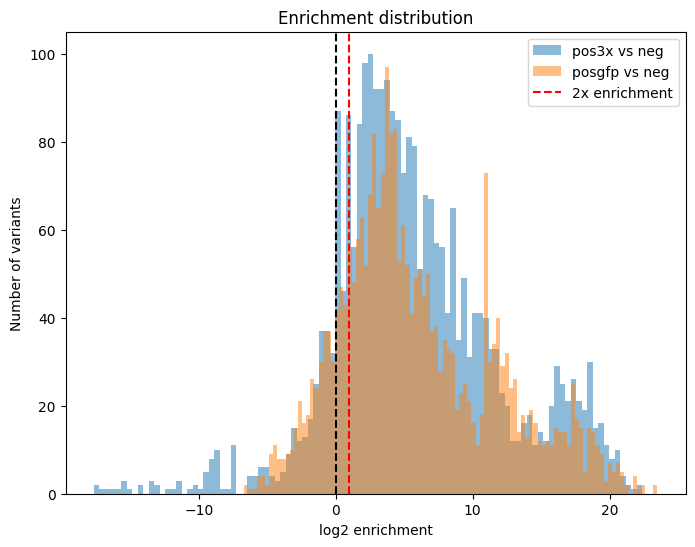

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Optional: filter out ultra-low count variants to reduce pseudocount artifacts
mask = merged["count_posgfp"] >= 5

plt.figure(figsize=(8,6))

plt.hist(
    merged.loc[mask, "log2_enrich_pos3x_vs_neg"],
    bins=100,
    alpha=0.5,
    label="pos3x vs neg"
)

plt.hist(
    merged.loc[mask, "log2_enrich_posgfp_vs_neg"],
    bins=100,
    alpha=0.5,
    label="posgfp vs neg"
)

plt.axvline(0, color="black", linestyle="--")
plt.axvline(1, color="red", linestyle="--", label="2x enrichment")

plt.xlabel("log2 enrichment")
plt.ylabel("Number of variants")
plt.legend()
plt.title("Enrichment distribution")
plt.show()


In [12]:
merged.head()

,aa_seq,count_lib,freq_lib,count_neg,freq_neg,count_pos3x,freq_pos3x,count_posgfp,freq_posgfp,enrich_pos3x_vs_neg,...,class_pos3x_vs_lib,class_posgfp_vs_lib,pass_min_pos3x,pass_min_posgfp,pass_min_neg,pass_min_lib,hit_posgfp,hit_pos3x,hit_both,hit_gfp_only
0,AGGANAADELF,89.0,1.364689e-05,81.0,1.460678e-05,0.0,0.0,0.0,0.0,0.000068,...,Depleted,Depleted,False,False,True,True,False,False,False,False
1,AGGANAADELY,2.0,3.066717e-07,1.0,1.803306e-07,0.0,0.0,0.0,0.0,0.005515,...,Depleted,Depleted,False,False,True,True,False,False,False,False
2,AGGANAADEQF,1.0,1.533358e-07,3.0,5.409918e-07,0.0,0.0,0.0,0.0,0.001845,...,Depleted,Depleted,False,False,True,True,False,False,False,False
3,AGGANAADEQY,30.0,4.600075e-06,42.0,7.573885e-06,0.0,0.0,0.0,0.0,0.000132,...,Depleted,Depleted,False,False,True,True,False,False,False,False
4,AGGANAADGLY,80.0,1.226687e-05,416.0,7.501752e-05,0.0,0.0,0.0,0.0,0.000013,...,Depleted,Depleted,False,False,True,True,False,False,False,False


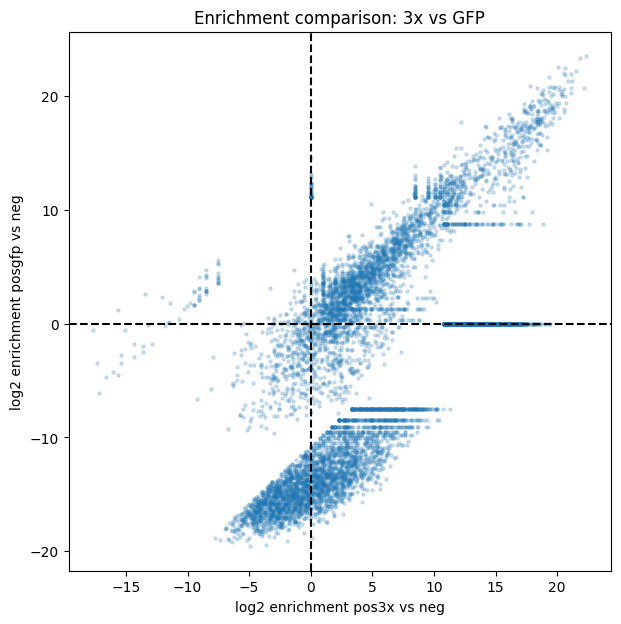

In [13]:
# Use same filtering
mask = (merged["count_posgfp"] >= 5) | (merged["count_pos3x"] >= 5)

plt.figure(figsize=(7,7))

plt.scatter(
    merged.loc[mask, "log2_enrich_pos3x_vs_neg"],
    merged.loc[mask, "log2_enrich_posgfp_vs_neg"],
    alpha=0.2,
    s=5
)

plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("log2 enrichment pos3x vs neg")
plt.ylabel("log2 enrichment posgfp vs neg")
plt.title("Enrichment comparison: 3x vs GFP")
plt.show()
